In [ ]:
from google.colab import files
uploaded = files.upload()

Saving realistic_kraljic_dataset.csv to realistic_kraljic_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


In [ ]:
df = pd.read_csv("realistic_kraljic_dataset.csv")
df.head()


,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category
0,P001,Semiconductors,South America,81,171,255.03,5,5,4,Yes,Strategic
1,P002,Semiconductors,South America,8,763,380.33,5,4,4,Yes,Strategic
2,P003,Pharma APIs,Asia,65,413,385.24,4,5,5,Yes,Strategic
3,P004,Semiconductors,South America,70,882,287.64,5,5,5,Yes,Strategic
4,P005,Lithium Batteries,Asia,15,120,382.26,4,4,4,Yes,Strategic


In [ ]:
X = df.drop("Kraljic_Category", axis=1)
X = X.select_dtypes(include=np.number) # Select only numeric columns
print(X)

     Lead_Time_Days  Order_Volume_Units  Cost_per_Unit  Supply_Risk_Score  \
0                81                 171         255.03                  5   
1                 8                 763         380.33                  5   
2                65                 413         385.24                  4   
3                70                 882         287.64                  5   
4                15                 120         382.26                  4   
..              ...                 ...            ...                ...   
995              19               19648          10.20                  2   
996              21               19143          15.30                  1   
997              70                5352          30.23                  1   
998              44               18070          30.73                  1   
999              76                9018          29.98                  1   

     Profit_Impact_Score  Environmental_Impact  
0                      5  

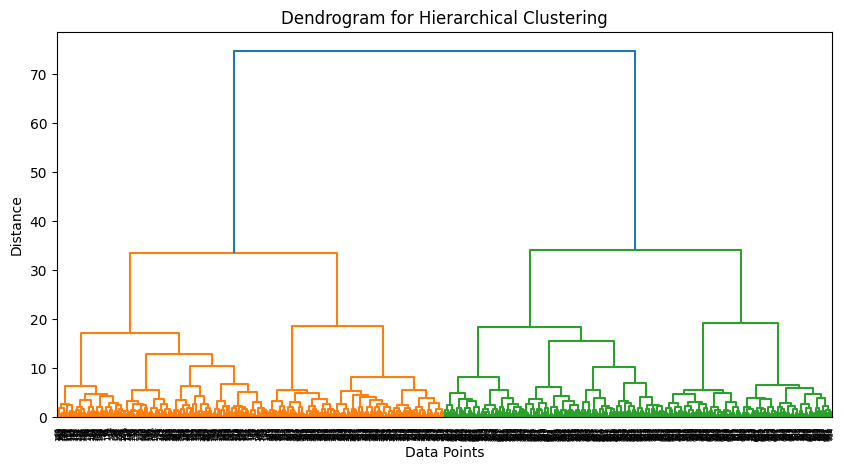

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(10, 5))
dendrogram(linkage(X_scaled, method='ward'))
plt.title("Dendrogram for Hierarchical Clustering")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

In [ ]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters = hc.fit_predict(X_scaled)


In [ ]:
df["Cluster"] = clusters
df.head()


,Product_ID,Product_Name,Supplier_Region,Lead_Time_Days,Order_Volume_Units,Cost_per_Unit,Supply_Risk_Score,Profit_Impact_Score,Environmental_Impact,Single_Source_Risk,Kraljic_Category,Cluster
0,P001,Semiconductors,South America,81,171,255.03,5,5,4,Yes,Strategic,3
1,P002,Semiconductors,South America,8,763,380.33,5,4,4,Yes,Strategic,3
2,P003,Pharma APIs,Asia,65,413,385.24,4,5,5,Yes,Strategic,3
3,P004,Semiconductors,South America,70,882,287.64,5,5,5,Yes,Strategic,3
4,P005,Lithium Batteries,Asia,15,120,382.26,4,4,4,Yes,Strategic,3


In [ ]:
df["Cluster"].value_counts()


,count
Cluster,
2,285
3,274
1,226
0,215


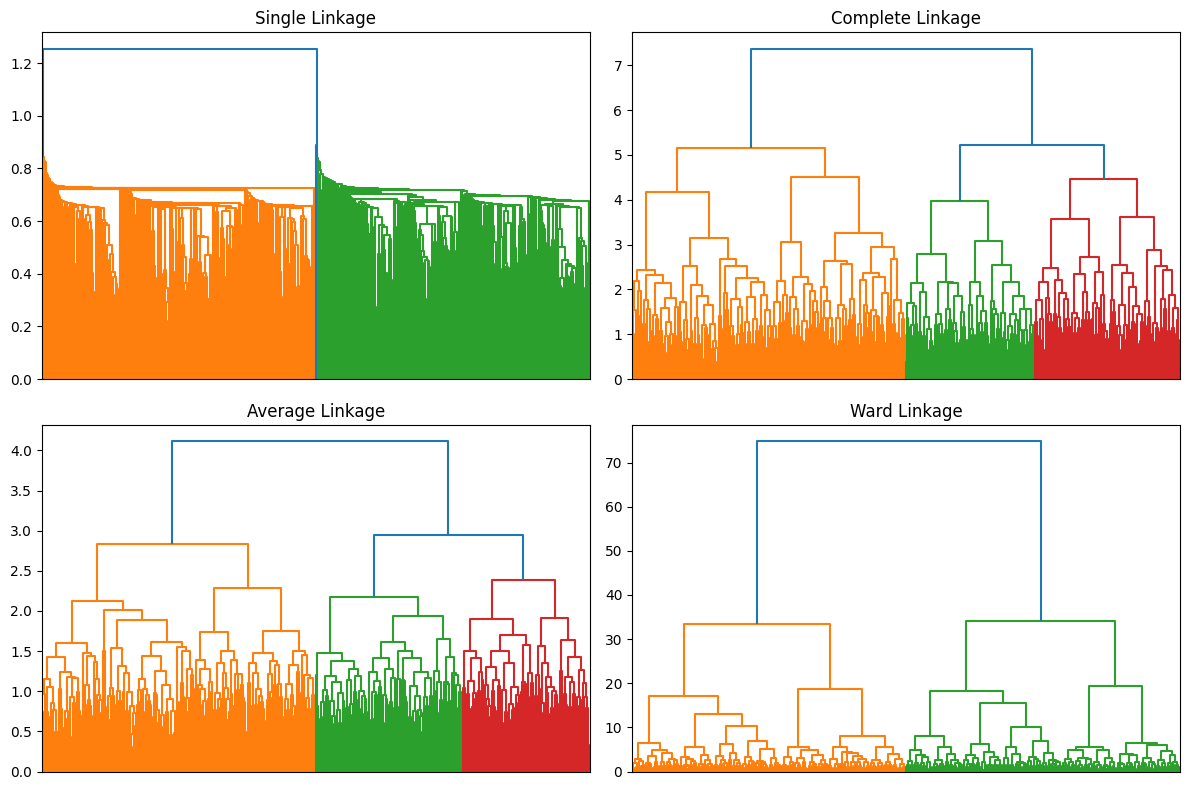

In [ ]:
methods = ['single', 'complete', 'average', 'ward']

plt.figure(figsize=(12, 8))
for i, method in enumerate(methods, 1):
    plt.subplot(2, 2, i)
    dendrogram(linkage(X_scaled, method=method), no_labels=True)
    plt.title(f"{method.capitalize()} Linkage")

plt.tight_layout()
plt.show()


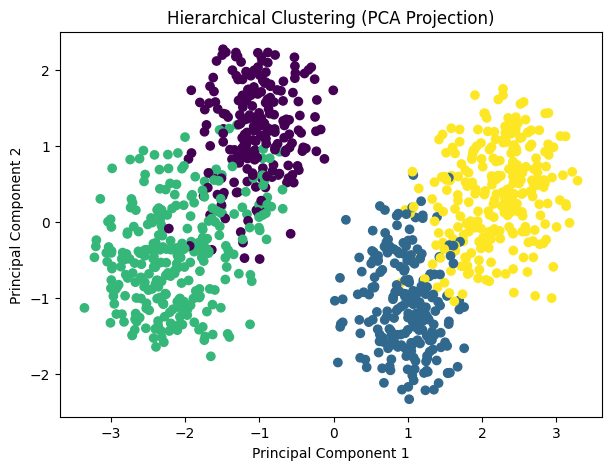

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.title("Hierarchical Clustering (PCA Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()


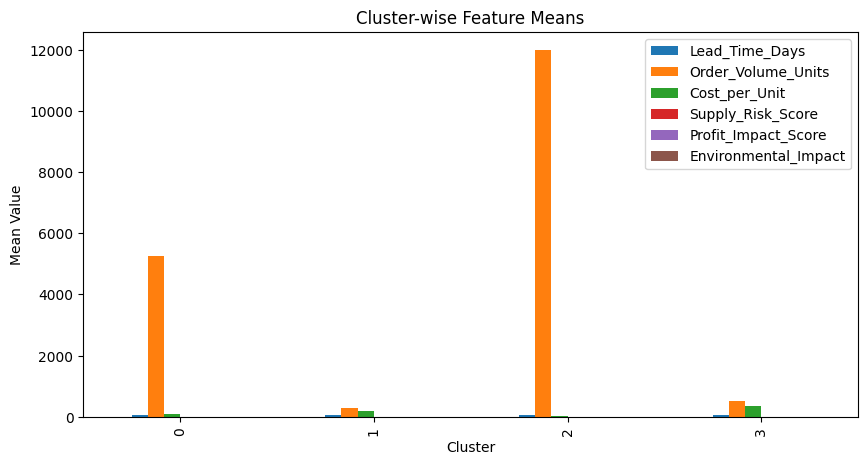

In [ ]:
cluster_means = df.groupby("Cluster").mean(numeric_only=True)

cluster_means.plot(kind='bar', figsize=(10, 5))
plt.title("Cluster-wise Feature Means")
plt.ylabel("Mean Value")
plt.show()

Hierarchical clustering was applied to the given dataset to group similar data points without using a target variable. The data was first standardized to ensure fair distance calculation between features. A dendrogram was created to visualize the hierarchical structure and to decide the optimal number of clusters. Different linkage methods such as single, complete, average, and ward were analyzed. Agglomerative clustering was then performed to assign cluster labels. Additional visualizations like PCA plots and cluster mean graphs helped in understanding cluster patterns and differences.
***
